# 🎾 Padel Analytics — Étape 5 : Séries Temporelles
## Partie F — Prévision du Nombre de Matchs par Mois

| | |
|---|---|
| **Objectif** | Prévoir le **nombre de matchs joués par mois** sur les prochains mois |
| **Modèles** | SARIMA · Prophet |
| **Évaluation** | MAPE · RMSE · MAE |

---
## 📦 0. Installation des dépendances spécifiques

In [3]:
# !pip install prophet statsmodels pmdarima

---
## 📚 1. Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine

# Statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Prophet
from prophet import Prophet

# Métriques
from sklearn.metrics import mean_squared_error, mean_absolute_error

print('✅ Imports OK')

✅ Imports OK


---
## 🔌 2. Chargement & Construction de la Série Temporelle

In [7]:
engine = create_engine('mysql+mysqlconnector://root:@127.0.0.1:3306/dw_padel_analytics')

fact_perf = pd.read_sql('SELECT * FROM fact_performance', engine)
dim_date  = pd.read_sql('SELECT * FROM dim_date',         engine)

# Jointure date
df = fact_perf.merge(dim_date[['DateKey','DateValue','Year','Month']], on='DateKey', how='left')
df['DateValue'] = pd.to_datetime(df['DateValue'])

# Agrégation mensuelle : nombre de matchs par mois
ts = df.groupby(df['DateValue'].dt.to_period('M')).size().reset_index()
ts.columns = ['Period', 'nb_matchs']
ts['ds'] = ts['Period'].dt.to_timestamp()
ts = ts.sort_values('ds').reset_index(drop=True)

print(f'Série temporelle : {len(ts)} mois')
print(f'Période : {ts["ds"].min().strftime("%Y-%m")} → {ts["ds"].max().strftime("%Y-%m")}')
display(ts.head(10))

Série temporelle : 36 mois
Période : 2023-01 → 2025-12


,Period,nb_matchs,ds
0,2023-01,8,2023-01-01
1,2023-02,33,2023-02-01
2,2023-03,87,2023-03-01
3,2023-04,71,2023-04-01
4,2023-05,92,2023-05-01
5,2023-06,72,2023-06-01
6,2023-07,37,2023-07-01
7,2023-08,31,2023-08-01
8,2023-09,15,2023-09-01
9,2023-10,33,2023-10-01


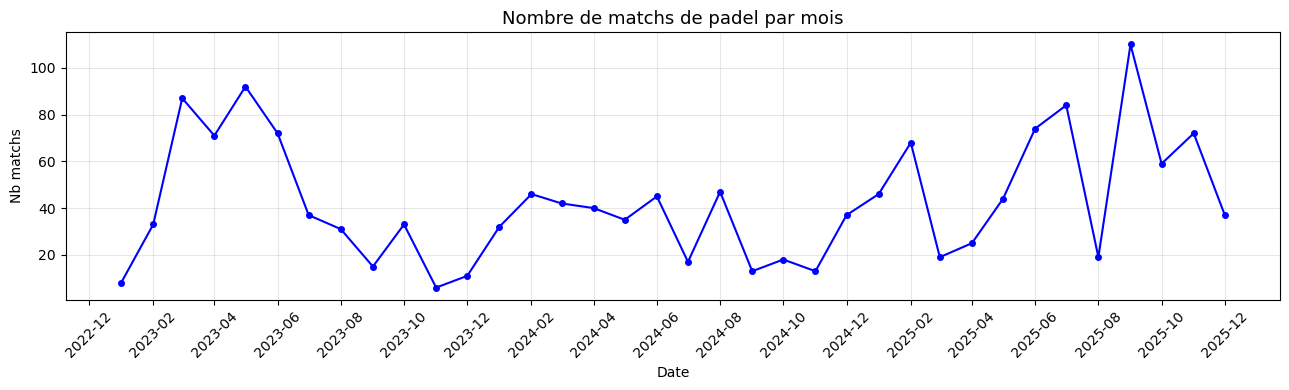

In [8]:
# Visualisation brute
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ts['ds'], ts['nb_matchs'], 'b-o', markersize=4, linewidth=1.5)
ax.set_title('Nombre de matchs de padel par mois', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Nb matchs')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🔍 3. Analyse de la Stationnarité
### 3.1 Test ADF (Augmented Dickey-Fuller)

In [10]:
series = ts['nb_matchs'].values

# Test ADF
adf_result = adfuller(series, autolag='AIC')
print('Test ADF (H0 : série non-stationnaire)')
print(f'  Statistique ADF : {adf_result[0]:.4f}')
print(f'  p-value         : {adf_result[1]:.4f}')
print(f'  Valeurs critiques : {adf_result[4]}')
if adf_result[1] < 0.05:
    print('  → ✅ Série STATIONNAIRE (rejette H0)')
else:
    print('  → ⚠️ Série NON-STATIONNAIRE (p > 0.05)')

Test ADF (H0 : série non-stationnaire)
  Statistique ADF : -2.7310
  p-value         : 0.0688
  Valeurs critiques : {'1%': -3.639224104416853, '5%': -2.9512301791166293, '10%': -2.614446989619377}
  → ⚠️ Série NON-STATIONNAIRE (p > 0.05)


In [11]:
# Test KPSS
kpss_result = kpss(series, regression='c', nlags='auto')
print('\nTest KPSS (H0 : série stationnaire)')
print(f'  Statistique KPSS : {kpss_result[0]:.4f}')
print(f'  p-value          : {kpss_result[1]:.4f}')
if kpss_result[1] > 0.05:
    print('  → ✅ Série STATIONNAIRE (ne rejette pas H0)')
else:
    print('  → ⚠️ Série NON-STATIONNAIRE (p < 0.05)')


Test KPSS (H0 : série stationnaire)
  Statistique KPSS : 0.1667
  p-value          : 0.1000
  → ✅ Série STATIONNAIRE (ne rejette pas H0)


C:\Users\arwaa\AppData\Local\Temp\ipykernel_18920\2596675483.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


### 3.2 Décomposition saisonnière

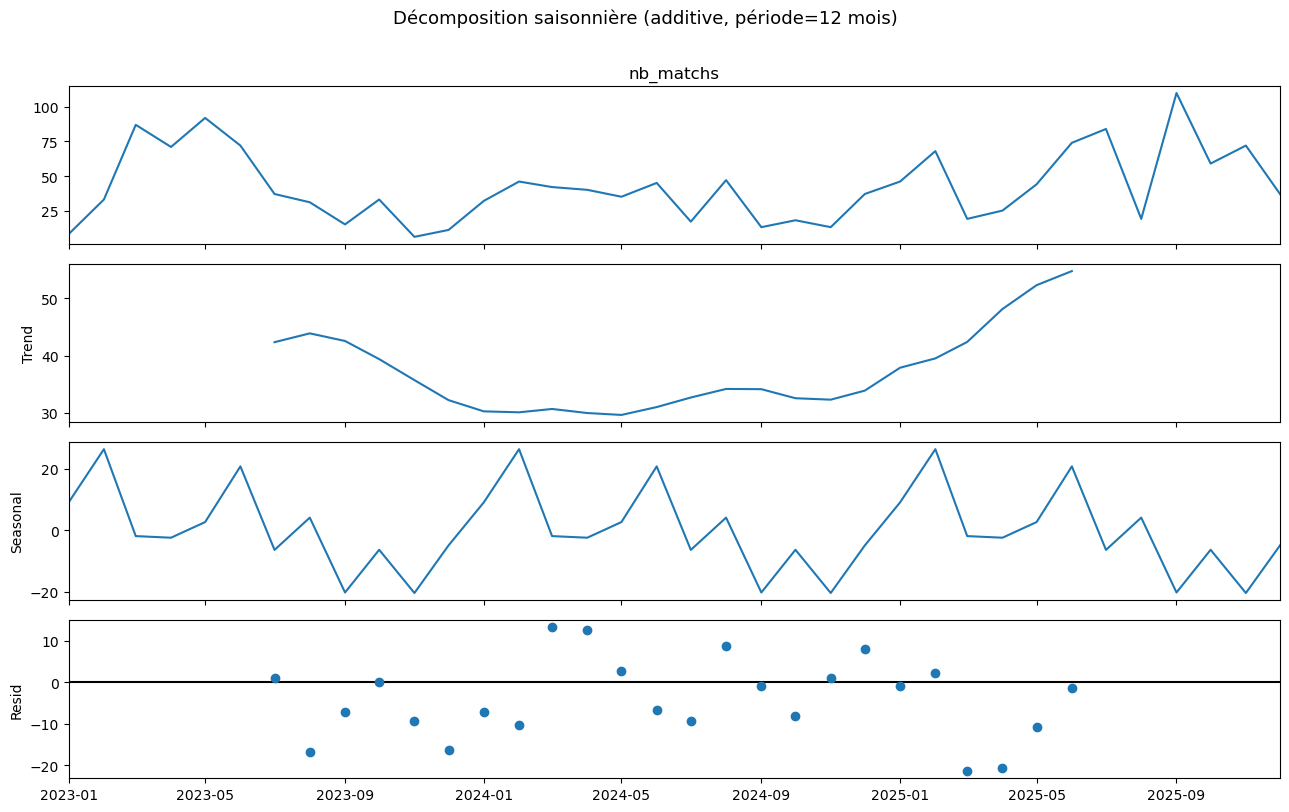

In [13]:
ts_indexed = ts.set_index('ds')['nb_matchs']
ts_indexed.index.freq = 'MS'  # Monthly Start

# Vérifier qu'on a assez de données (min 2 cycles)
if len(ts_indexed) >= 24:
    decomp = seasonal_decompose(ts_indexed, model='additive', period=12)
    fig = decomp.plot()
    fig.set_size_inches(13, 8)
    fig.suptitle('Décomposition saisonnière (additive, période=12 mois)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print(f'⚠️ Seulement {len(ts_indexed)} mois disponibles — décomposition avec période={len(ts_indexed)//2}')
    period = max(2, len(ts_indexed)//2)
    decomp = seasonal_decompose(ts_indexed, model='additive', period=period)
    fig = decomp.plot()
    fig.set_size_inches(13, 8)
    plt.tight_layout()
    plt.show()

### 3.3 ACF / PACF

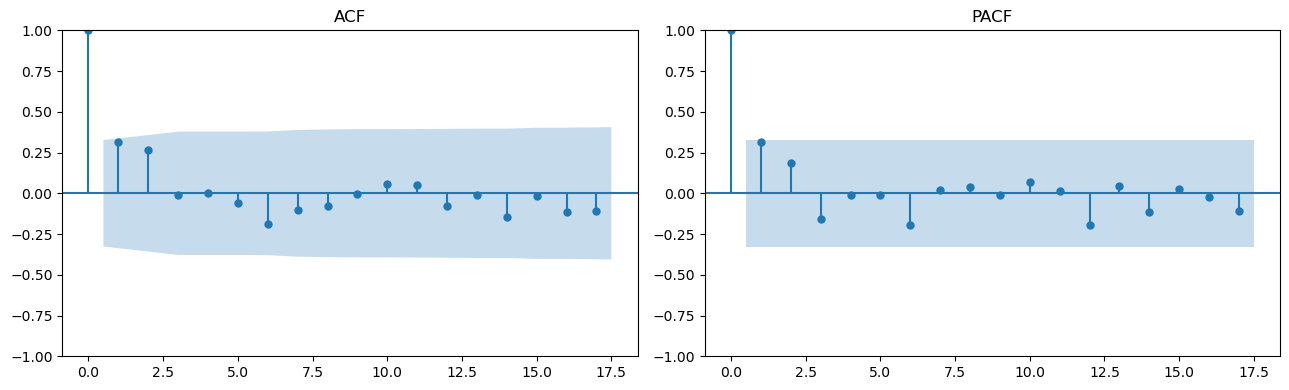

ACF/PACF aident à choisir les ordres p, d, q pour SARIMA.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf( ts_indexed, lags=min(20, len(ts_indexed)//2 - 1), ax=axes[0], title='ACF')
plot_pacf(ts_indexed, lags=min(20, len(ts_indexed)//2 - 1), ax=axes[1], title='PACF', method='ywm')
plt.tight_layout()
plt.show()
print('ACF/PACF aident à choisir les ordres p, d, q pour SARIMA.')

---
## 🧠 F — Compréhension des Modèles

### SARIMA (Seasonal ARIMA)
**Intuition :** Modèle statistique qui combine ARIMA avec une composante saisonnière.  

---
## ✂️ 4. Train/Test Split (Hold-out 20%)

In [18]:
n = len(ts)
split_idx = int(n * 0.8)

train_ts = ts.iloc[:split_idx]
test_ts  = ts.iloc[split_idx:]

print(f'Train : {len(train_ts)} mois ({train_ts["ds"].min().strftime("%Y-%m")} → {train_ts["ds"].max().strftime("%Y-%m")})')
print(f'Test  : {len(test_ts)}  mois ({test_ts["ds"].min().strftime("%Y-%m")} → {test_ts["ds"].max().strftime("%Y-%m")})')

train_series = train_ts.set_index('ds')['nb_matchs']
test_series  = test_ts.set_index('ds')['nb_matchs']

Train : 28 mois (2023-01 → 2025-04)
Test  : 8  mois (2025-05 → 2025-12)


---
## 📈 F.1 — Modèle SARIMA

In [20]:
# Paramètres SARIMA — ajuster selon ACF/PACF
# Si série courte : utiliser ordre simple (1,1,1)(1,1,0,12) ou (1,0,0)(0,1,1,12)

order_s = (1, 1, 1)   # (p, d, q)

# Choisir la période saisonnière selon longueur des données
S = 12 if len(train_series) >= 24 else max(2, len(train_series) // 3)
seasonal_order_s = (1, 0, 1, S)  # (P, D, Q, S)

print(f'SARIMA{order_s}{seasonal_order_s} — entraînement...')

sarima_model = SARIMAX(
    train_series,
    order=order_s,
    seasonal_order=seasonal_order_s,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

SARIMA(1, 1, 1)(1, 0, 1, 12) — entraînement...


C:\Users\arwaa\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\arwaa\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          nb_matchs   No. Observations:                   28
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                 -53.179
Date:                            Wed, 22 Apr 2026   AIC                            116.358
Time:                                    14:00:03   BIC                            119.183
Sample:                                01-01-2023   HQIC                           115.777
                                     - 04-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0185      0.074    -13.676      0.000      -1.164      -0.873
ma.L1          1.0000   3.06e+04   

In [21]:
# Prédiction sur test
n_test = len(test_ts)
sarima_forecast = sarima_fit.forecast(steps=n_test)
sarima_forecast = np.maximum(sarima_forecast, 0)  # pas de valeurs négatives

# Métriques SARIMA
y_true = test_series.values
rmse_s = np.sqrt(mean_squared_error(y_true, sarima_forecast))
mae_s  = mean_absolute_error(y_true, sarima_forecast)
mape_s = np.mean(np.abs((y_true - sarima_forecast) / (y_true + 1e-9))) * 100

print(f'SARIMA — Métriques sur le test set :')
print(f'  RMSE : {rmse_s:.2f}')
print(f'  MAE  : {mae_s:.2f}')
print(f'  MAPE : {mape_s:.2f}%')

SARIMA — Métriques sur le test set :
  RMSE : 60.80
  MAE  : 51.75
  MAPE : 80.69%


## 🔮 F.2 — Modèle Prophet

In [23]:
# Format Prophet : colonnes 'ds' et 'y'
train_prophet = train_ts[['ds', 'nb_matchs']].rename(columns={'nb_matchs': 'y'})
test_prophet  = test_ts[['ds', 'nb_matchs']].rename(columns={'nb_matchs': 'y'})

# Entraînement Prophet
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.1,
    interval_width=0.95
)
prophet_model.fit(train_prophet)

# Prédiction
future = prophet_model.make_future_dataframe(periods=n_test + 6, freq='MS')
prophet_forecast = prophet_model.predict(future)

# Métriques sur test
y_pred_prophet = prophet_forecast[prophet_forecast['ds'].isin(test_ts['ds'])]['yhat'].values
y_pred_prophet = np.maximum(y_pred_prophet[:n_test], 0)

rmse_p = np.sqrt(mean_squared_error(y_true[:len(y_pred_prophet)], y_pred_prophet))
mae_p  = mean_absolute_error(y_true[:len(y_pred_prophet)], y_pred_prophet)
mape_p = np.mean(np.abs((y_true[:len(y_pred_prophet)] - y_pred_prophet) / (y_true[:len(y_pred_prophet)] + 1e-9))) * 100

print(f'Prophet — Métriques sur le test set :')
print(f'  RMSE : {rmse_p:.2f}')
print(f'  MAE  : {mae_p:.2f}')
print(f'  MAPE : {mape_p:.2f}%')

14:00:05 - cmdstanpy - INFO - Chain [1] start processing
14:00:08 - cmdstanpy - INFO - Chain [1] done processing


Prophet — Métriques sur le test set :
  RMSE : 55.58
  MAE  : 45.06
  MAPE : 67.47%


## 📊 F.3 — Comparaison SARIMA vs Prophet

In [25]:
ts_results = pd.DataFrame({
    'Modèle': ['SARIMA', 'Prophet'],
    'RMSE'  : [round(rmse_s, 2), round(rmse_p, 2)],
    'MAE'   : [round(mae_s,  2), round(mae_p,  2)],
    'MAPE %': [round(mape_s, 2), round(mape_p, 2)]
}).set_index('Modèle')

print('📊 COMPARAISON SERIES TEMPORELLES')
display(ts_results.style.highlight_min(axis=0, color='lightgreen'))

📊 COMPARAISON SERIES TEMPORELLES


,RMSE,MAE,MAPE %
Modèle,,,
SARIMA,60.800000,51.750000,80.690000
Prophet,55.580000,45.060000,67.470000


## 📈 F.4 — Visualisation des Prévisions

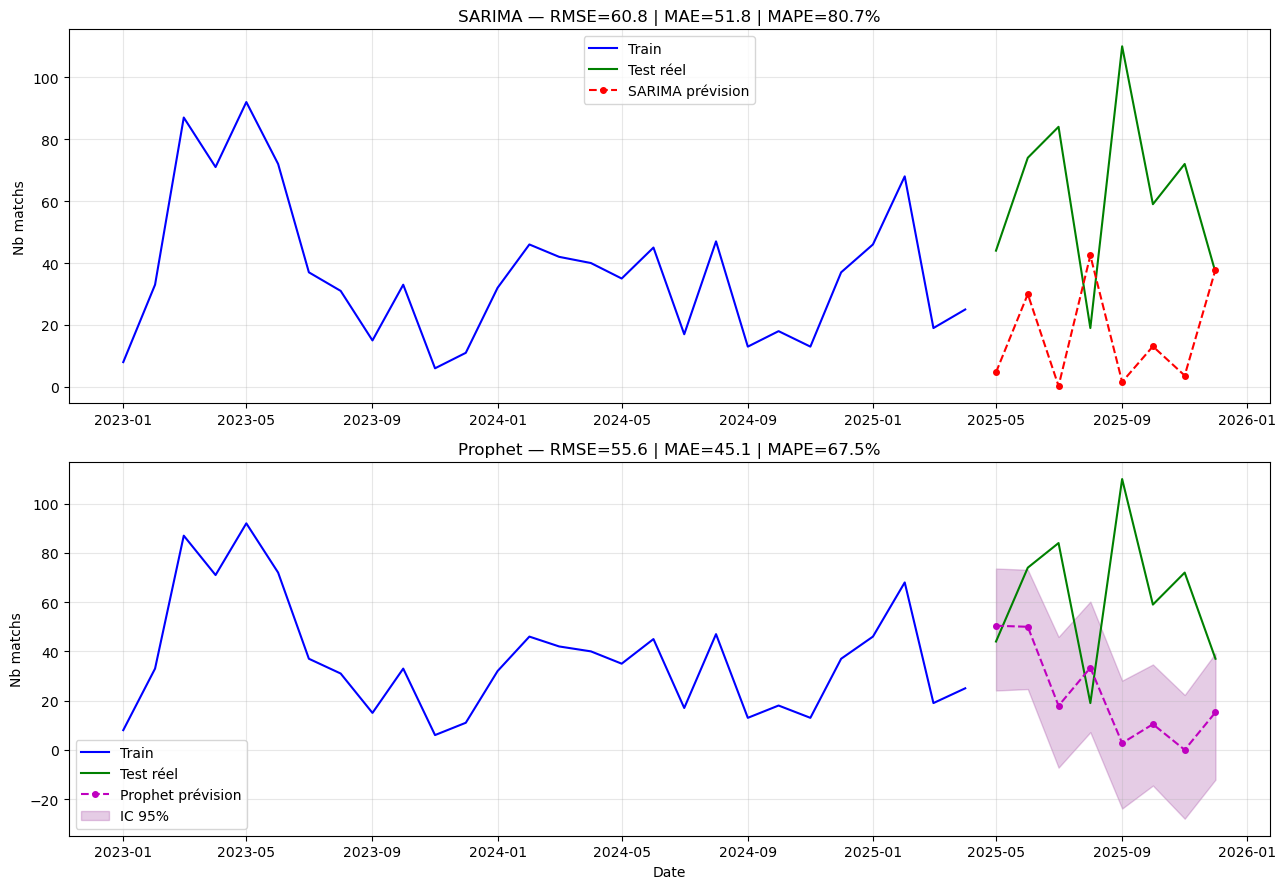

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# --- SARIMA ---
axes[0].plot(train_ts['ds'], train_ts['nb_matchs'], 'b-', label='Train', linewidth=1.5)
axes[0].plot(test_ts['ds'],  y_true,                'g-', label='Test réel', linewidth=1.5)
axes[0].plot(test_ts['ds'],  sarima_forecast,        'r--o', label='SARIMA prévision',
             markersize=4, linewidth=1.5)
axes[0].set_title(f'SARIMA — RMSE={rmse_s:.1f} | MAE={mae_s:.1f} | MAPE={mape_s:.1f}%', fontsize=12)
axes[0].set_ylabel('Nb matchs')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Prophet ---
axes[1].plot(train_ts['ds'], train_ts['nb_matchs'], 'b-', label='Train', linewidth=1.5)
axes[1].plot(test_ts['ds'],  y_true,                'g-', label='Test réel', linewidth=1.5)
axes[1].plot(test_ts['ds'],  y_pred_prophet,        'm--o', label='Prophet prévision',
             markersize=4, linewidth=1.5)

# Intervalle de confiance Prophet
fc_test = prophet_forecast[prophet_forecast['ds'].isin(test_ts['ds'])].iloc[:n_test]
axes[1].fill_between(fc_test['ds'], fc_test['yhat_lower'], fc_test['yhat_upper'],
                     alpha=0.2, color='purple', label='IC 95%')

axes[1].set_title(f'Prophet — RMSE={rmse_p:.1f} | MAE={mae_p:.1f} | MAPE={mape_p:.1f}%', fontsize=12)
axes[1].set_ylabel('Nb matchs')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 🔮 F.5 — Prévision Future (6 mois)

🔮 Prévision Prophet — 6 prochains mois :


,Date,Prévision,IC Bas,IC Haut
36,2026-01-01,18,0,43
37,2026-02-01,43,17,69
38,2026-03-01,42,18,70
39,2026-04-01,32,7,58
40,2026-05-01,50,25,75
41,2026-06-01,40,14,68


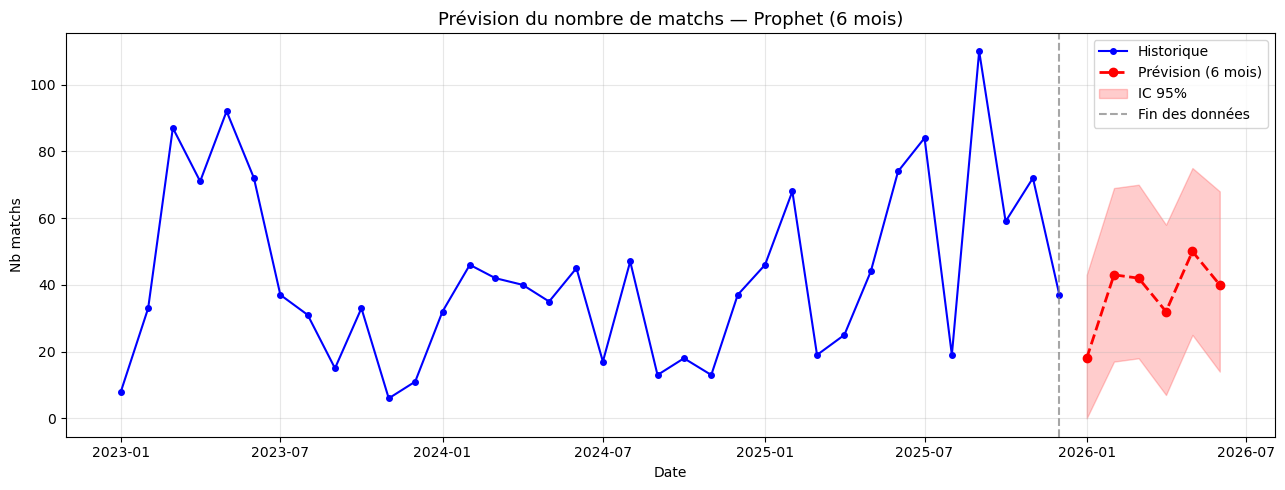

In [29]:
# Prévision Prophet sur les 6 prochains mois
future_6 = prophet_forecast[prophet_forecast['ds'] > ts['ds'].max()][['ds','yhat','yhat_lower','yhat_upper']].head(6)
future_6.columns = ['Date', 'Prévision', 'IC Bas', 'IC Haut']
future_6['Prévision'] = future_6['Prévision'].clip(lower=0).round(0).astype(int)
future_6['IC Bas']    = future_6['IC Bas'].clip(lower=0).round(0).astype(int)
future_6['IC Haut']   = future_6['IC Haut'].clip(lower=0).round(0).astype(int)

print('🔮 Prévision Prophet — 6 prochains mois :')
display(future_6)

# Visualisation finale
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts['ds'], ts['nb_matchs'], 'b-o', markersize=4, label='Historique', linewidth=1.5)
ax.plot(future_6['Date'], future_6['Prévision'], 'r--o', markersize=6,
        label='Prévision (6 mois)', linewidth=2)
ax.fill_between(future_6['Date'], future_6['IC Bas'], future_6['IC Haut'],
                alpha=0.2, color='red', label='IC 95%')
ax.axvline(ts['ds'].max(), color='gray', linestyle='--', alpha=0.7, label='Fin des données')
ax.set_title('Prévision du nombre de matchs — Prophet (6 mois)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Nb matchs')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 📌 F.6 — Composantes Prophet

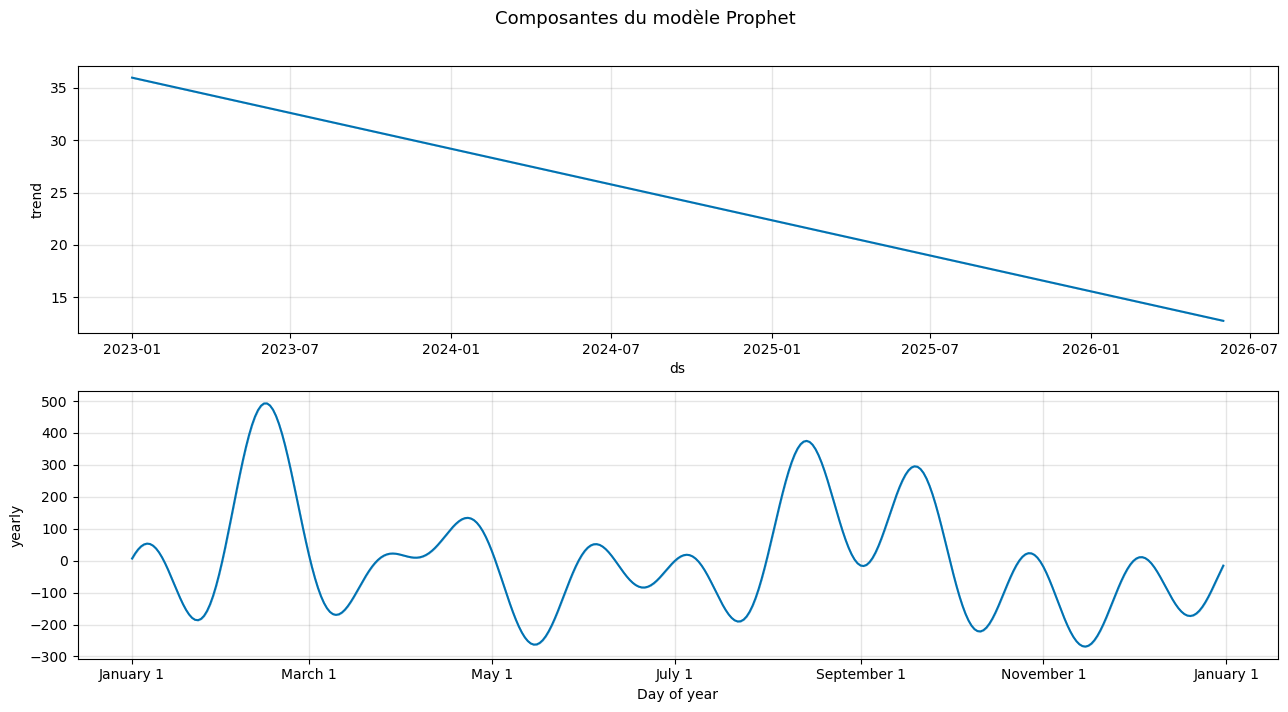

In [31]:
fig2 = prophet_model.plot_components(prophet_forecast)
fig2.set_size_inches(13, 7)
plt.suptitle('Composantes du modèle Prophet', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 📋 F.7 — Résumé

In [33]:
print('=' * 60)
print('📋 RÉSUMÉ SÉRIES TEMPORELLES')
print('=' * 60)
display(ts_results)

best_ts = ts_results['MAPE %'].idxmin()
print(f'\n🏆 Meilleur modèle : {best_ts} (MAPE = {ts_results.loc[best_ts,"MAPE %"]:.2f}%)')
print('\n📌 Conclusion :')
print('Prophet offre plus de flexibilité pour les séries avec saisonnalité')
print('irrégulière et fournit des intervalles de confiance directement.')
print('SARIMA est plus interprétable statistiquement et adapté aux séries')
print('courtes et bien structurées.')

📋 RÉSUMÉ SÉRIES TEMPORELLES


,RMSE,MAE,MAPE %
Modèle,,,
SARIMA,60.80,51.75,80.69
Prophet,55.58,45.06,67.47



🏆 Meilleur modèle : Prophet (MAPE = 67.47%)

📌 Conclusion :
Prophet offre plus de flexibilité pour les séries avec saisonnalité
irrégulière et fournit des intervalles de confiance directement.
SARIMA est plus interprétable statistiquement et adapté aux séries
courtes et bien structurées.
